In [ ]:
!pip install xgboost lightgbm shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('yield_df.csv')
print(df.shape)
df.head()

Saving yield_df.csv to yield_df.csv
(28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


In [ ]:
# Check for duplicates — this dataset is known to have some
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

0
(28242, 8)


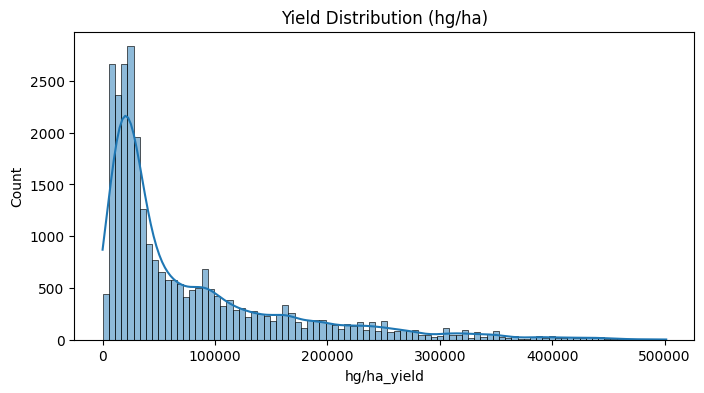

In [ ]:
# Target distribution
plt.figure(figsize=(8,4))
sns.histplot(df['hg/ha_yield'], kde=True)
plt.title('Yield Distribution (hg/ha)')
plt.show()

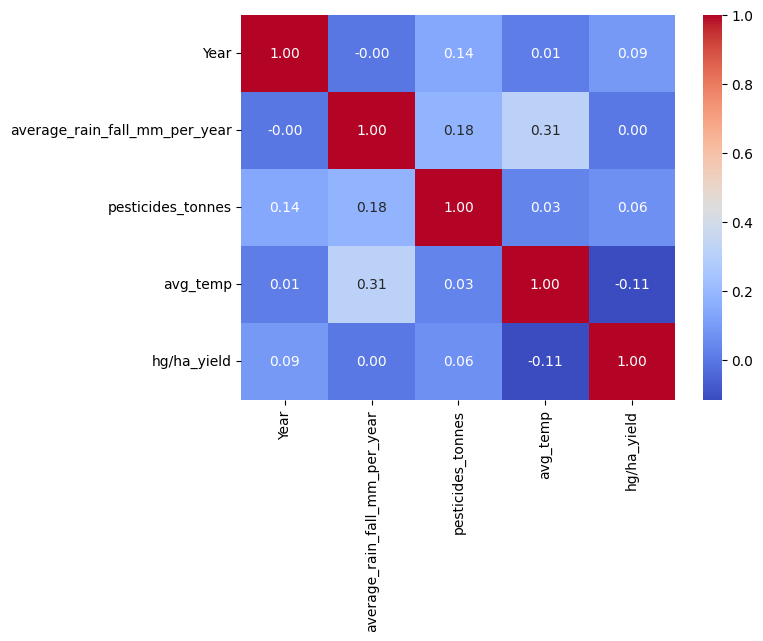

In [ ]:
# Numeric correlation
numeric_cols = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'hg/ha_yield']
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

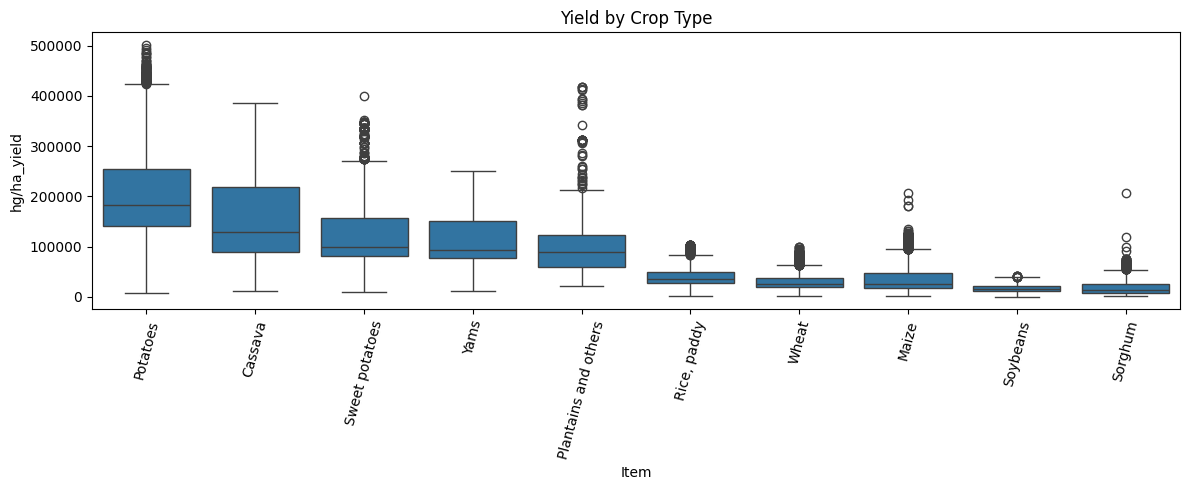

In [ ]:
# Yield by crop — expect BIG differences here (this is usually the strongest feature)
plt.figure(figsize=(12,5))
order = df.groupby('Item')['hg/ha_yield'].median().sort_values(ascending=False).index
sns.boxplot(x='Item', y='hg/ha_yield', data=df, order=order)
plt.xticks(rotation=75)
plt.title('Yield by Crop Type')
plt.tight_layout()
plt.show()

In [ ]:
# Top/bottom countries by average yield
top_areas = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False)
print(top_areas.head(10))
print(top_areas.tail(10))

Area
United Kingdom    240956.478261
Belgium           216468.461538
Denmark           214033.020000
Netherlands       204151.202899
Ireland           197913.695652
New Zealand       191931.826087
Sweden            187405.500000
Bahrain           153237.551724
Norway            146115.326087
Switzerland       144960.282609
Name: hg/ha_yield, dtype: float64
Area
Nepal                       35771.417391
Angola                      34893.676829
Ecuador                     34324.623188
Burundi                     33966.888889
Madagascar                  33171.320652
Burkina Faso                33061.614130
Mauritania                  27738.142857
Central African Republic    26432.465839
Eritrea                     18155.200000
Botswana                     7353.921875
Name: hg/ha_yield, dtype: float64


In [ ]:
# ANOVA check — confirm Item and Area are significant (they will be, unlike last time)
from scipy import stats
for col in ['Item', 'Area']:
    groups = [g['hg/ha_yield'].values for _, g in df.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col}: F-stat={f_stat:.2f}, p-value={p_val:.10f}")

Item: F-stat=4881.45, p-value=0.0000000000
Area: F-stat=48.01, p-value=0.0000000000


In [ ]:
# Rainfall efficiency — rain relative to temp (can matter for crop stress)
df['rain_temp_ratio'] = df['average_rain_fall_mm_per_year'] / (df['avg_temp'] + 1)

# Pesticide intensity per unit rainfall (proxy for input intensity)
df['pesticide_per_rain'] = df['pesticides_tonnes'] / (df['average_rain_fall_mm_per_year'] + 1)

# Decade feature — yield tends to trend up over time due to tech/farming improvements
df['decade'] = (df['Year'] // 10) * 10

In [ ]:
target = 'hg/ha_yield'
X = df.drop(columns=[target])
y = df[target]

numeric_features = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes',
                     'avg_temp', 'rain_temp_ratio', 'pesticide_per_rain', 'decade']
categorical_features = ['Area', 'Item']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
results = {}

rf_pipe = Pipeline([('preprocessor', preprocessor),
                     ('model', RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
results['Random Forest'] = rf_pipe

xgb_pipe = Pipeline([('preprocessor', preprocessor),
                      ('model', xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, random_state=42))])
xgb_pipe.fit(X_train, y_train)
results['XGBoost'] = xgb_pipe

lgb_pipe = Pipeline([('preprocessor', preprocessor),
                      ('model', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, random_state=42))])
lgb_pipe.fit(X_train, y_train)
results['LightGBM'] = lgb_pipe

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1360
[LightGBM] [Info] Number of data points in the train set: 22593, number of used features: 118
[LightGBM] [Info] Start training from score 77051.197760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

           Model          RMSE          MAE        R2
0  Random Forest   9914.082822  4340.493820  0.986450
1        XGBoost  11294.232156  6306.815430  0.982414
2       LightGBM  16039.693461  9294.256958  0.964532


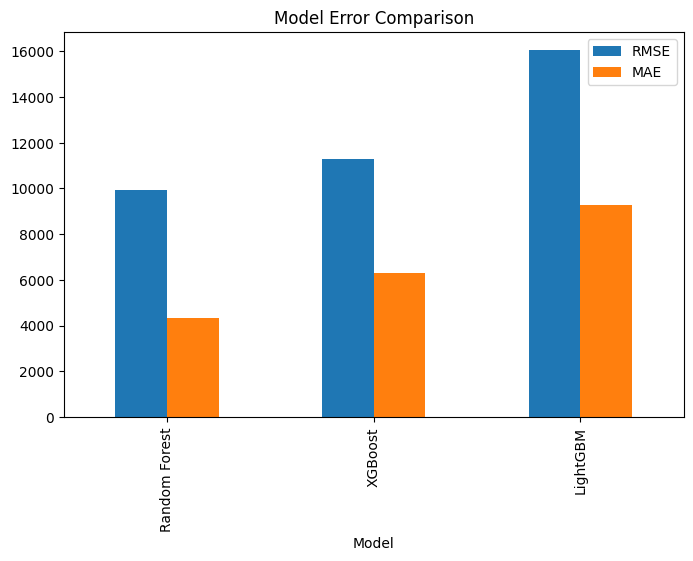

In [ ]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

scores_df = pd.DataFrame([evaluate(n, m, X_test, y_test) for n, m in results.items()]).sort_values('R2', ascending=False)
print(scores_df)

scores_df.set_index('Model')[['RMSE','MAE']].plot(kind='bar', figsize=(8,5))
plt.title('Model Error Comparison')
plt.show()

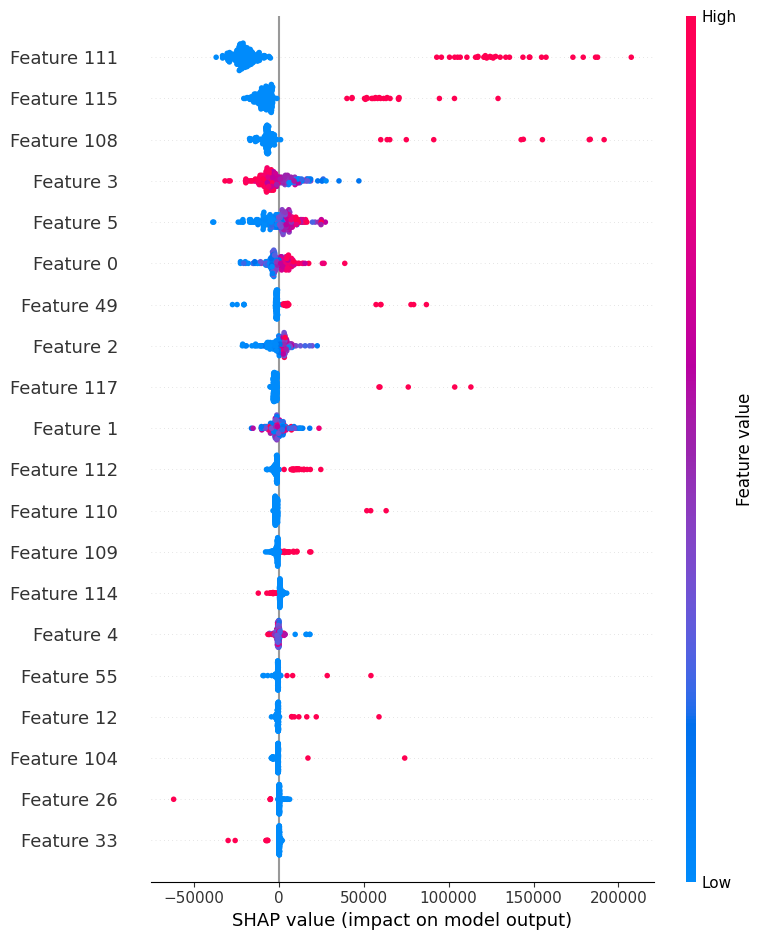

In [ ]:
import shap

best_name = scores_df.iloc[0]['Model']
best_pipe = results[best_name]

X_test_transformed = best_pipe.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Use TreeExplainer explicitly — much faster for tree-based models than generic Explainer
explainer = shap.TreeExplainer(best_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed[:200])  # smaller sample
shap.summary_plot(shap_values, X_test_transformed[:200])

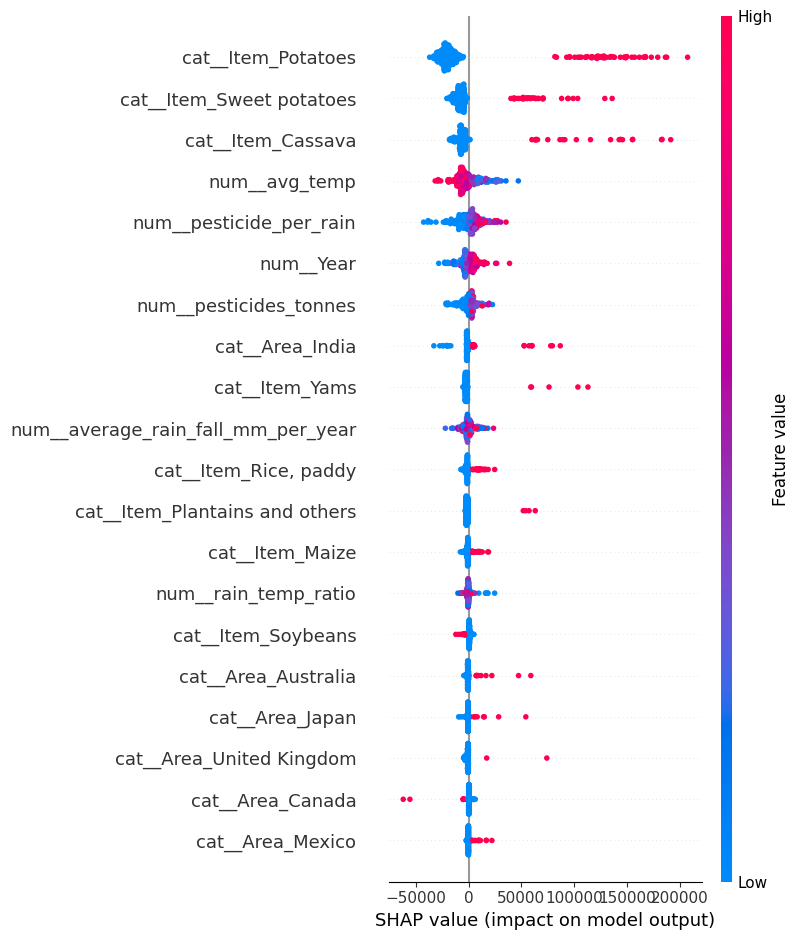

In [ ]:
# Get the actual feature names from the preprocessor
feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()

# Re-run SHAP with real names
X_test_transformed = best_pipe.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(best_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed[:300])

shap.summary_plot(shap_values, X_test_transformed[:300], feature_names=feature_names)

In [ ]:
import joblib

if best_name == 'XGBoost':
    best_pipe.named_steps['model'].save_model('crop_yield_xgb.json')
else:
    joblib.dump(best_pipe.named_steps['model'], 'crop_yield_model.pkl')

joblib.dump(best_pipe.named_steps['preprocessor'], 'preprocessor.pkl')

['preprocessor.pkl']

ValueError: mount failed